In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns

from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

#aesthetics
# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 900

def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))


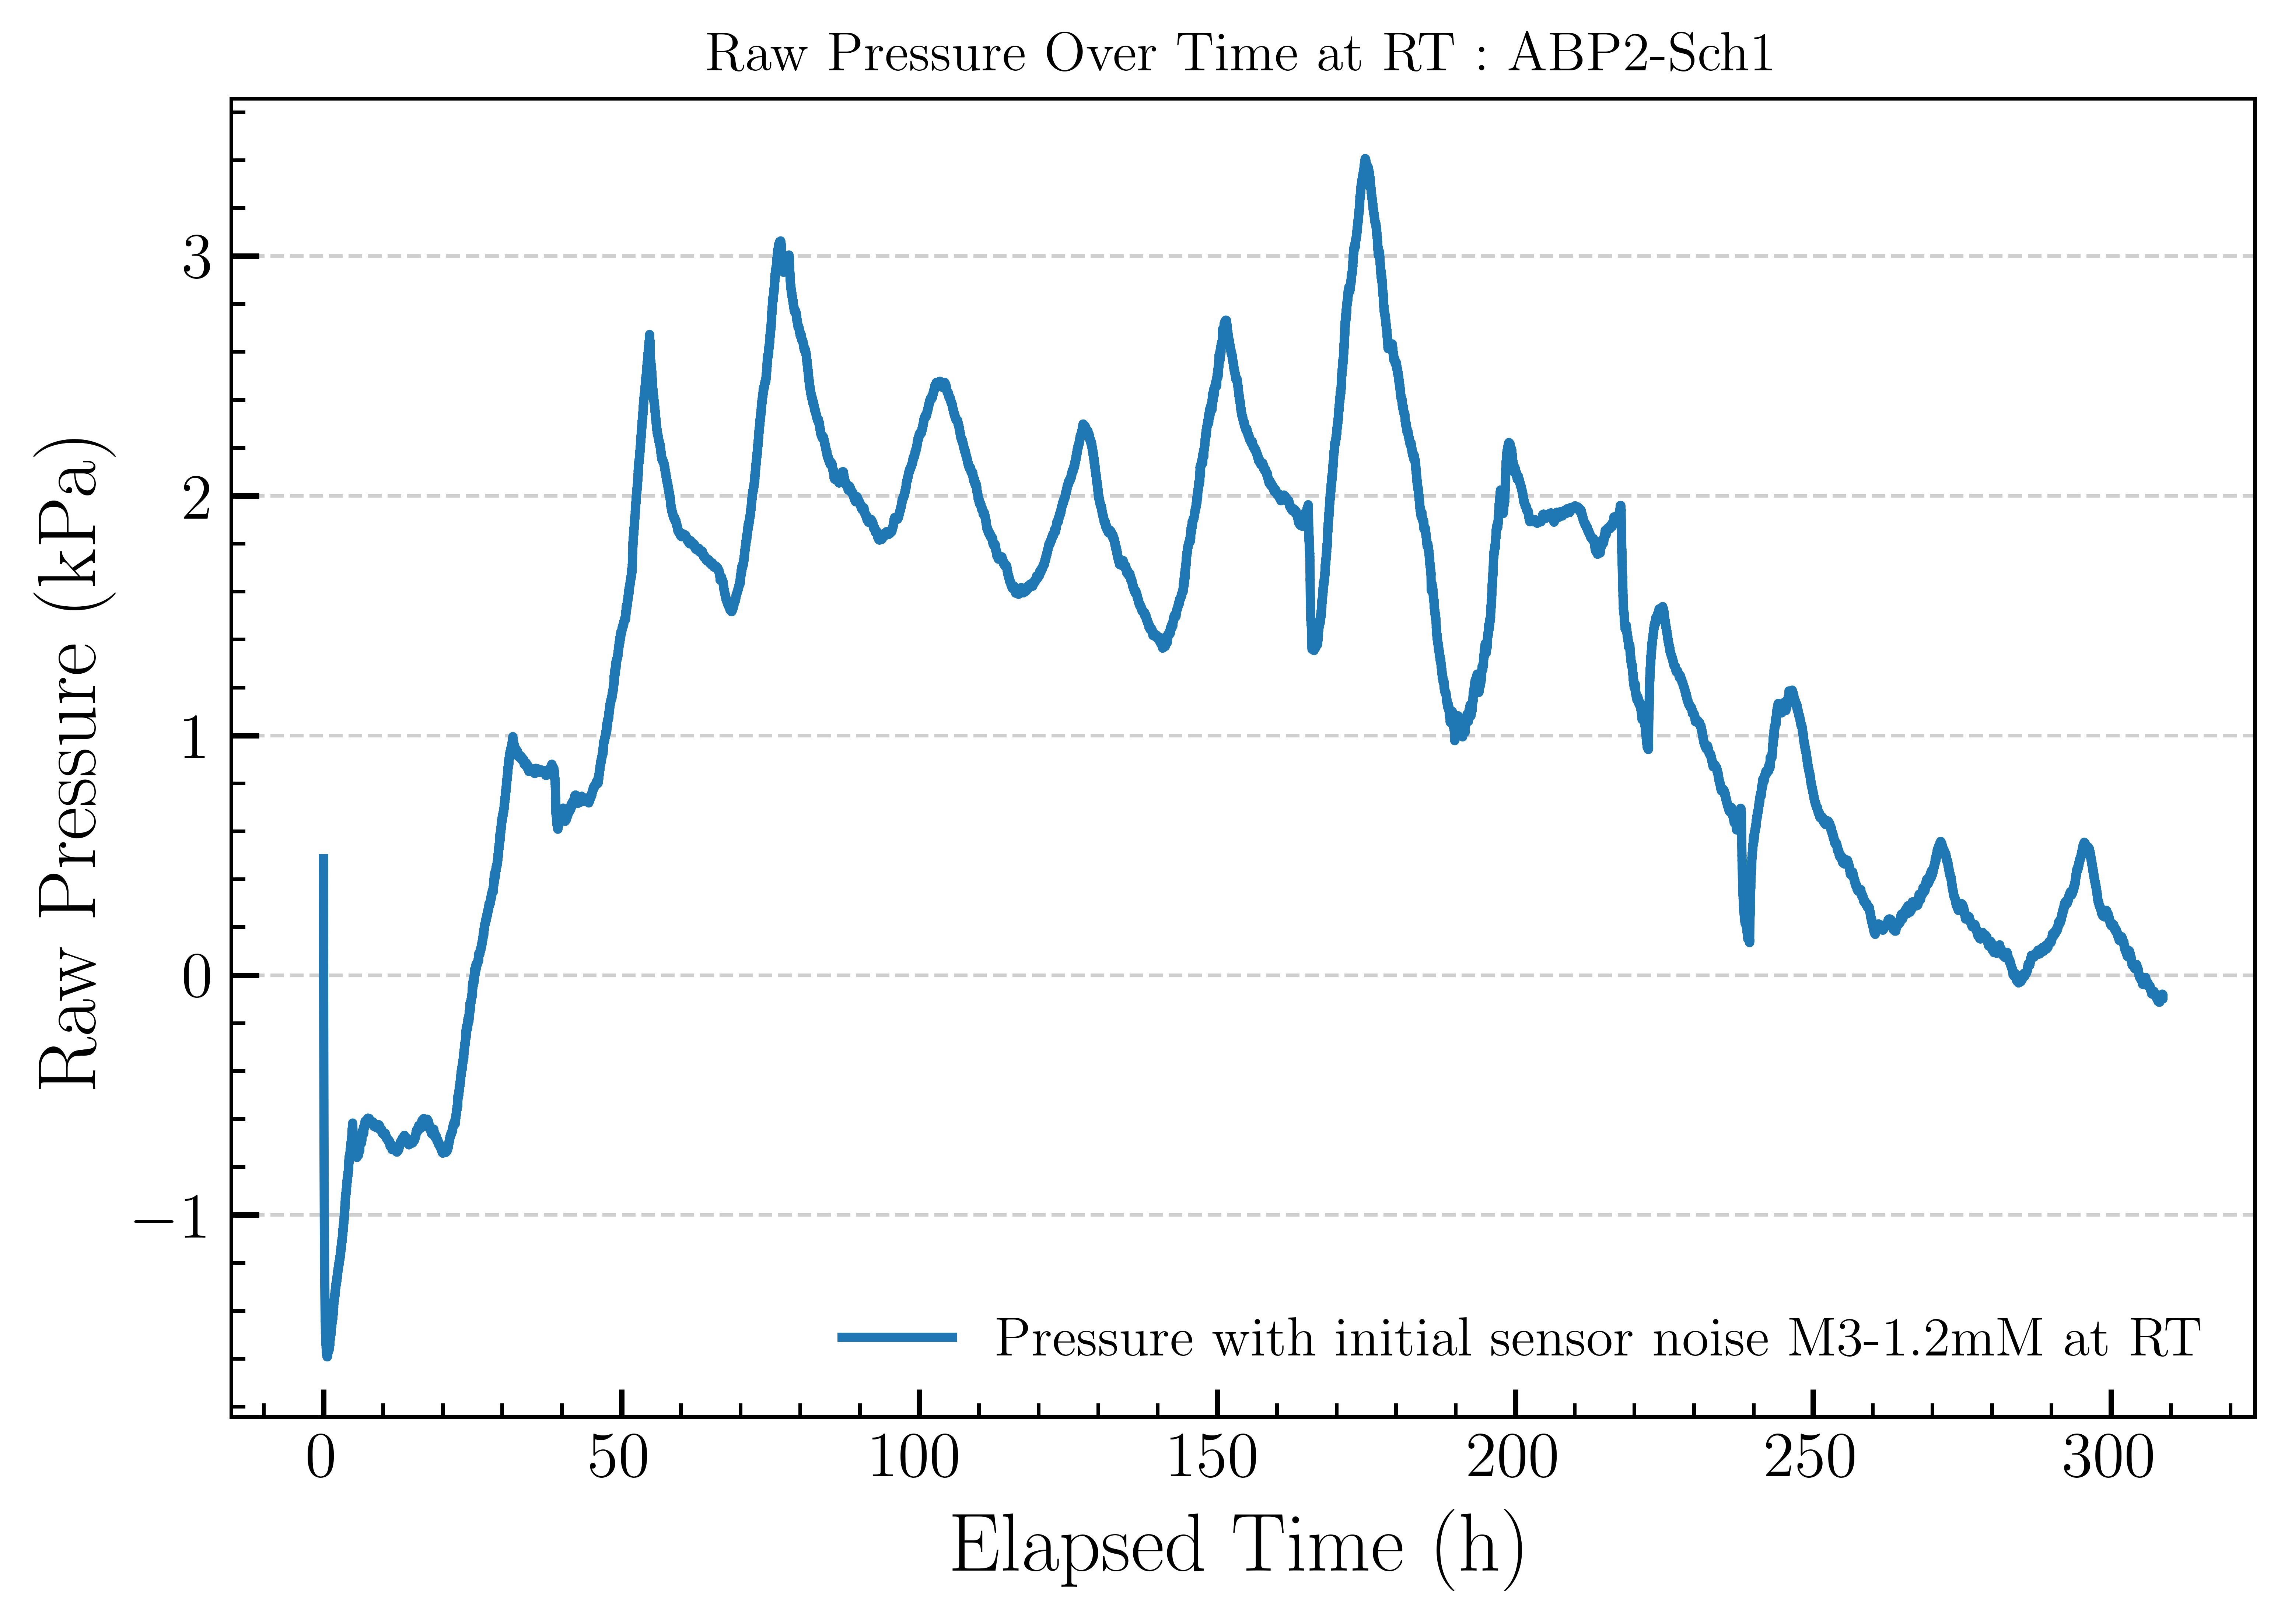

In [2]:
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\merged_pressure_log_RT.csv"



df = pd.read_csv(main_path)
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df["Elapsed Time (hours)"], df["ABP2-Sch1 (kPa)"], lw=2.0, color="tab:blue", label=r'Pressure with initial sensor noise M3-1.2mM at RT')
ax1.set_title('Raw Pressure Over Time at RT : ABP2-Sch1')
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel=" Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()


         Date       Time  ABP2-Sch1 (kPa)  MPR-Sch2 (kPa)  Temperature (C)  \
0  12.08.2025   11:31:01           0.4862         99.0163            27.49   
1  12.08.2025   11:31:02           0.4709         99.0104            27.45   
2  12.08.2025   11:31:03           0.4657         99.0091            27.46   
3  12.08.2025   11:31:05           0.4589         99.0032            27.44   
4  12.08.2025   11:31:06           0.4501         98.9922            27.43   

   Humidity (%RH)             Datetime  Elapsed Time (hours)  Weekday  \
0           54.06  2025-08-12 11:31:01              0.000000  Tuesday   
1           53.87  2025-08-12 11:31:02              0.000278  Tuesday   
2           53.82  2025-08-12 11:31:03              0.000556  Tuesday   
3           53.68  2025-08-12 11:31:05              0.001111  Tuesday   
4           53.52  2025-08-12 11:31:06              0.001389  Tuesday   

   Is_Weekend  Is_Midnight  Logical_Day  
0       False        False            0  
1       

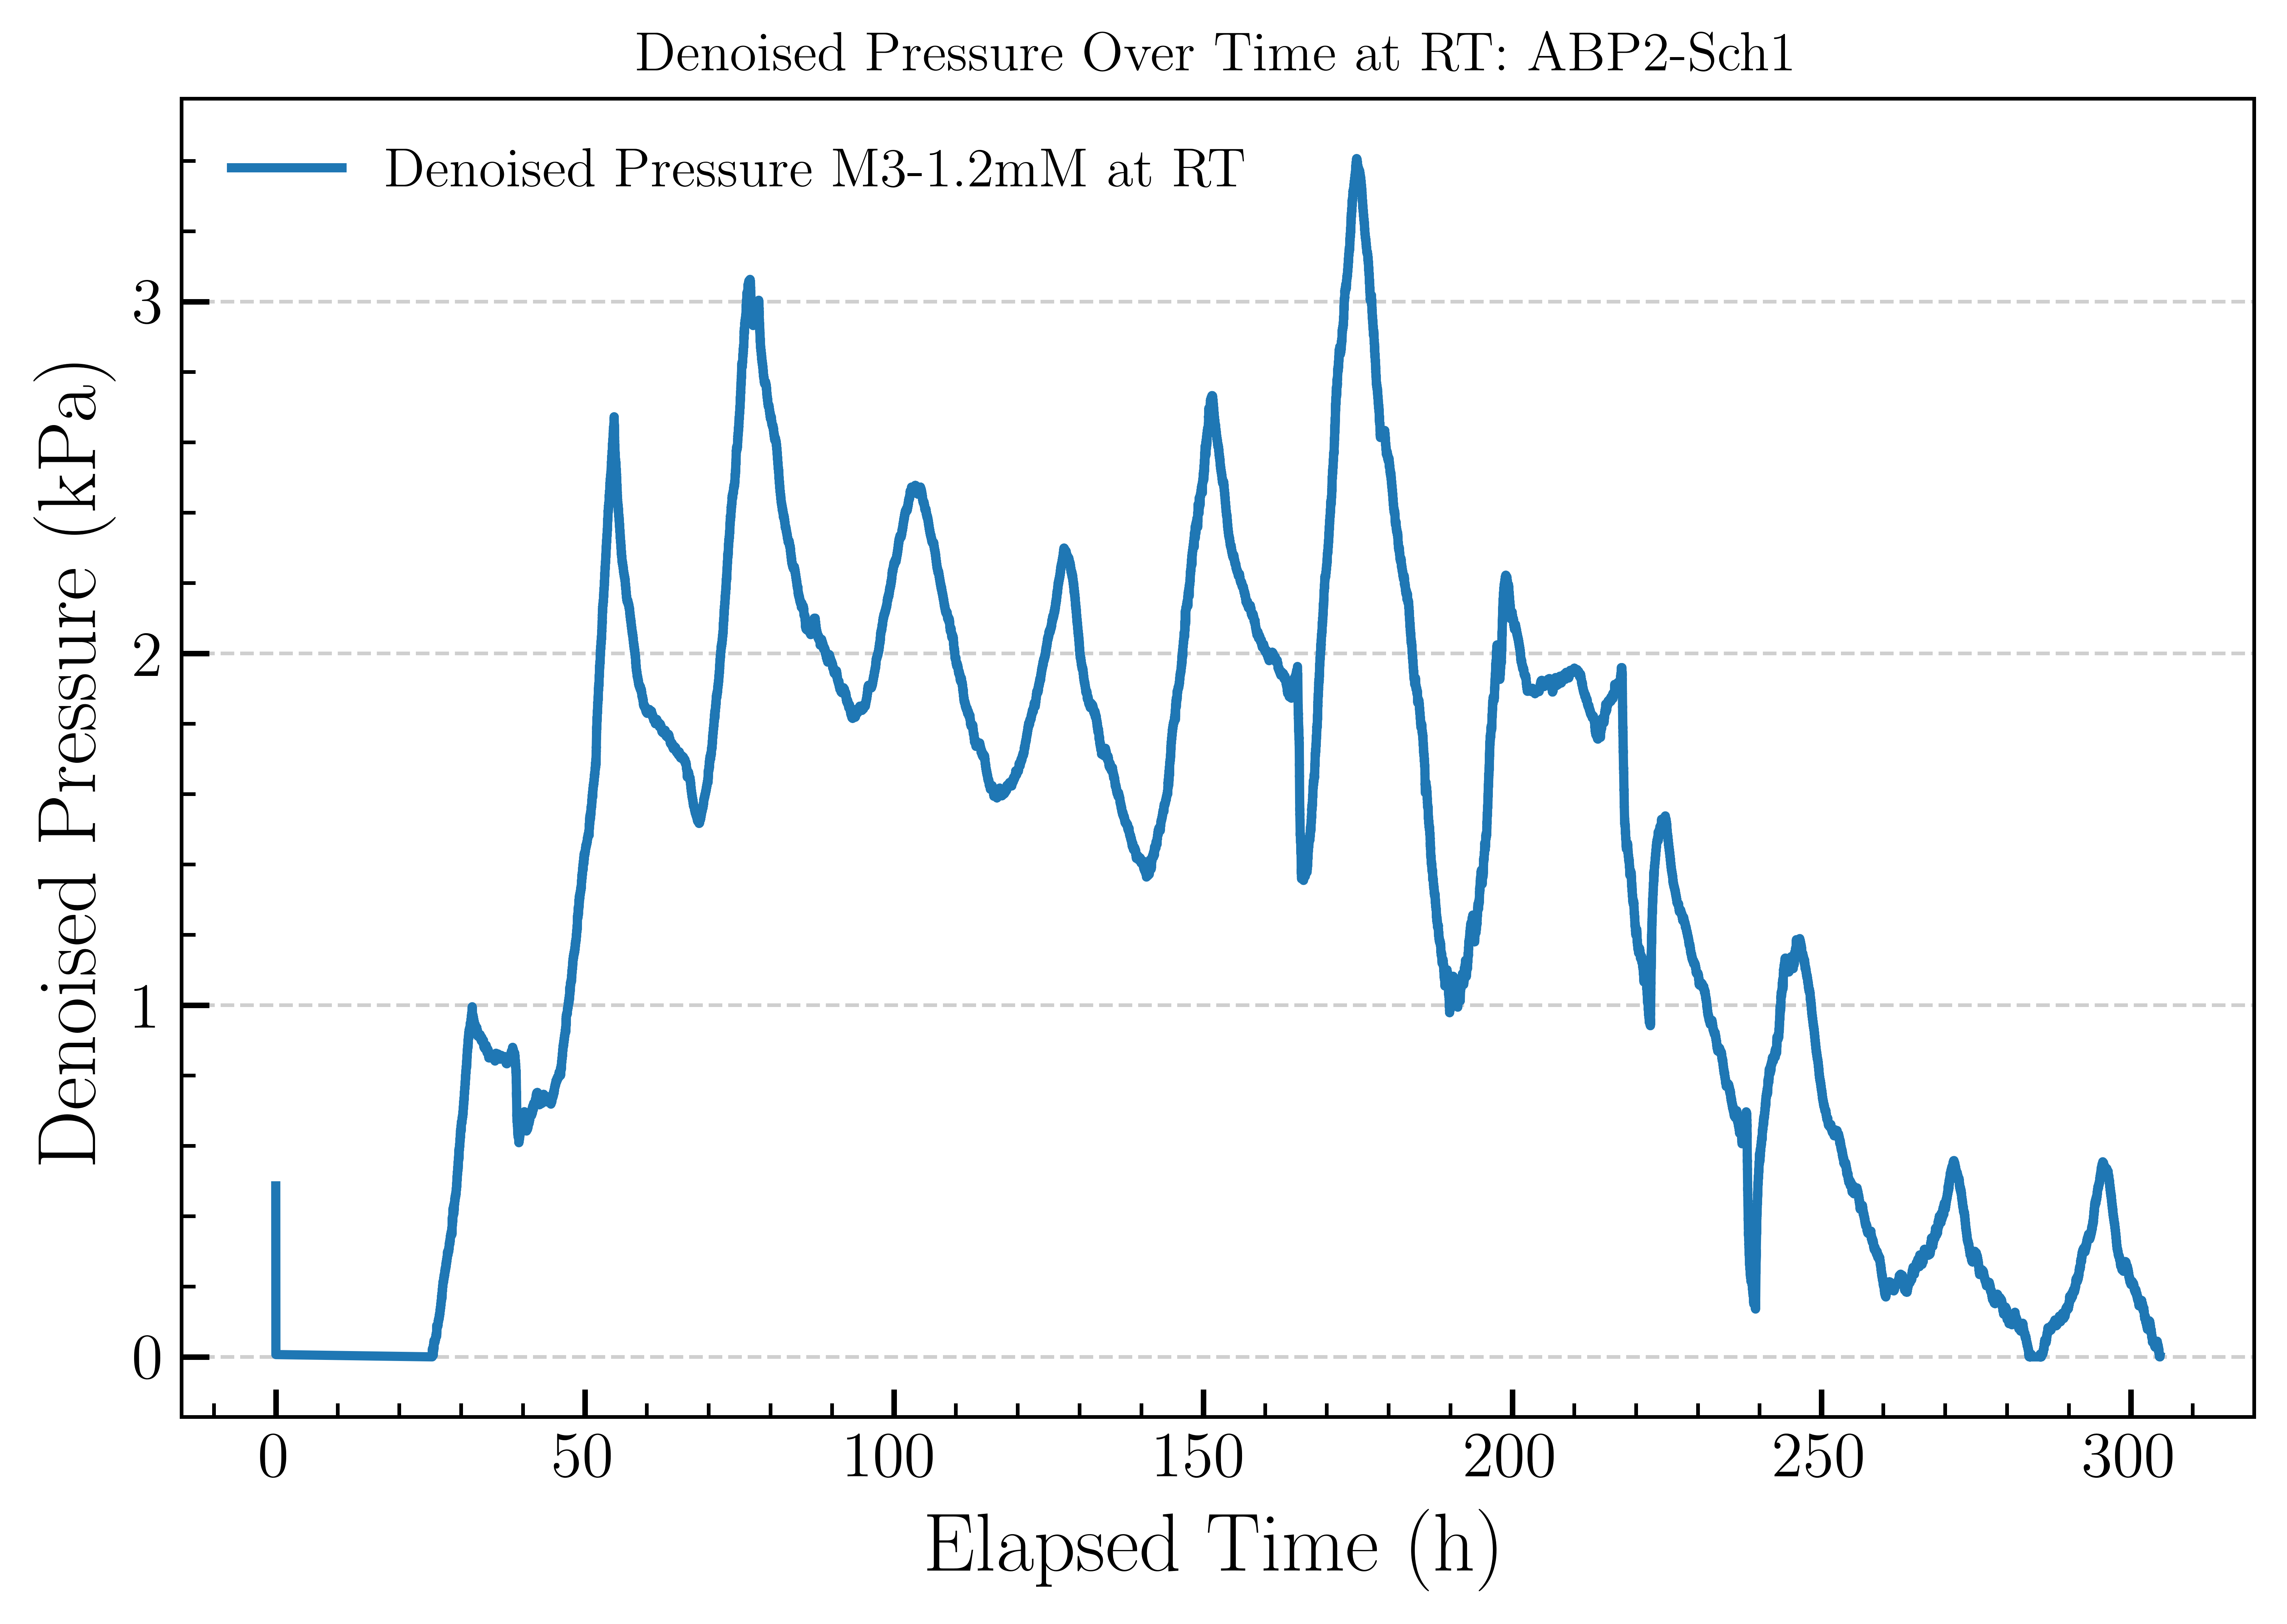

In [9]:
df_trimmed = df[df["ABP2-Sch1 (kPa)"] >= 0].reset_index(drop=True)

print(df_trimmed.head())
# pd.DataFrame(df_trimmed).to_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\denoised_pressure_log_RT.csv", index=False)

fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_trimmed["Elapsed Time (hours)"], df_trimmed["ABP2-Sch1 (kPa)"], label=r"Denoised Pressure M3-1.2mM at RT", lw=2.0, color="tab:blue")
ax1.set_title("Denoised Pressure Over Time at RT: ABP2-Sch1")
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel=" Denoised Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()


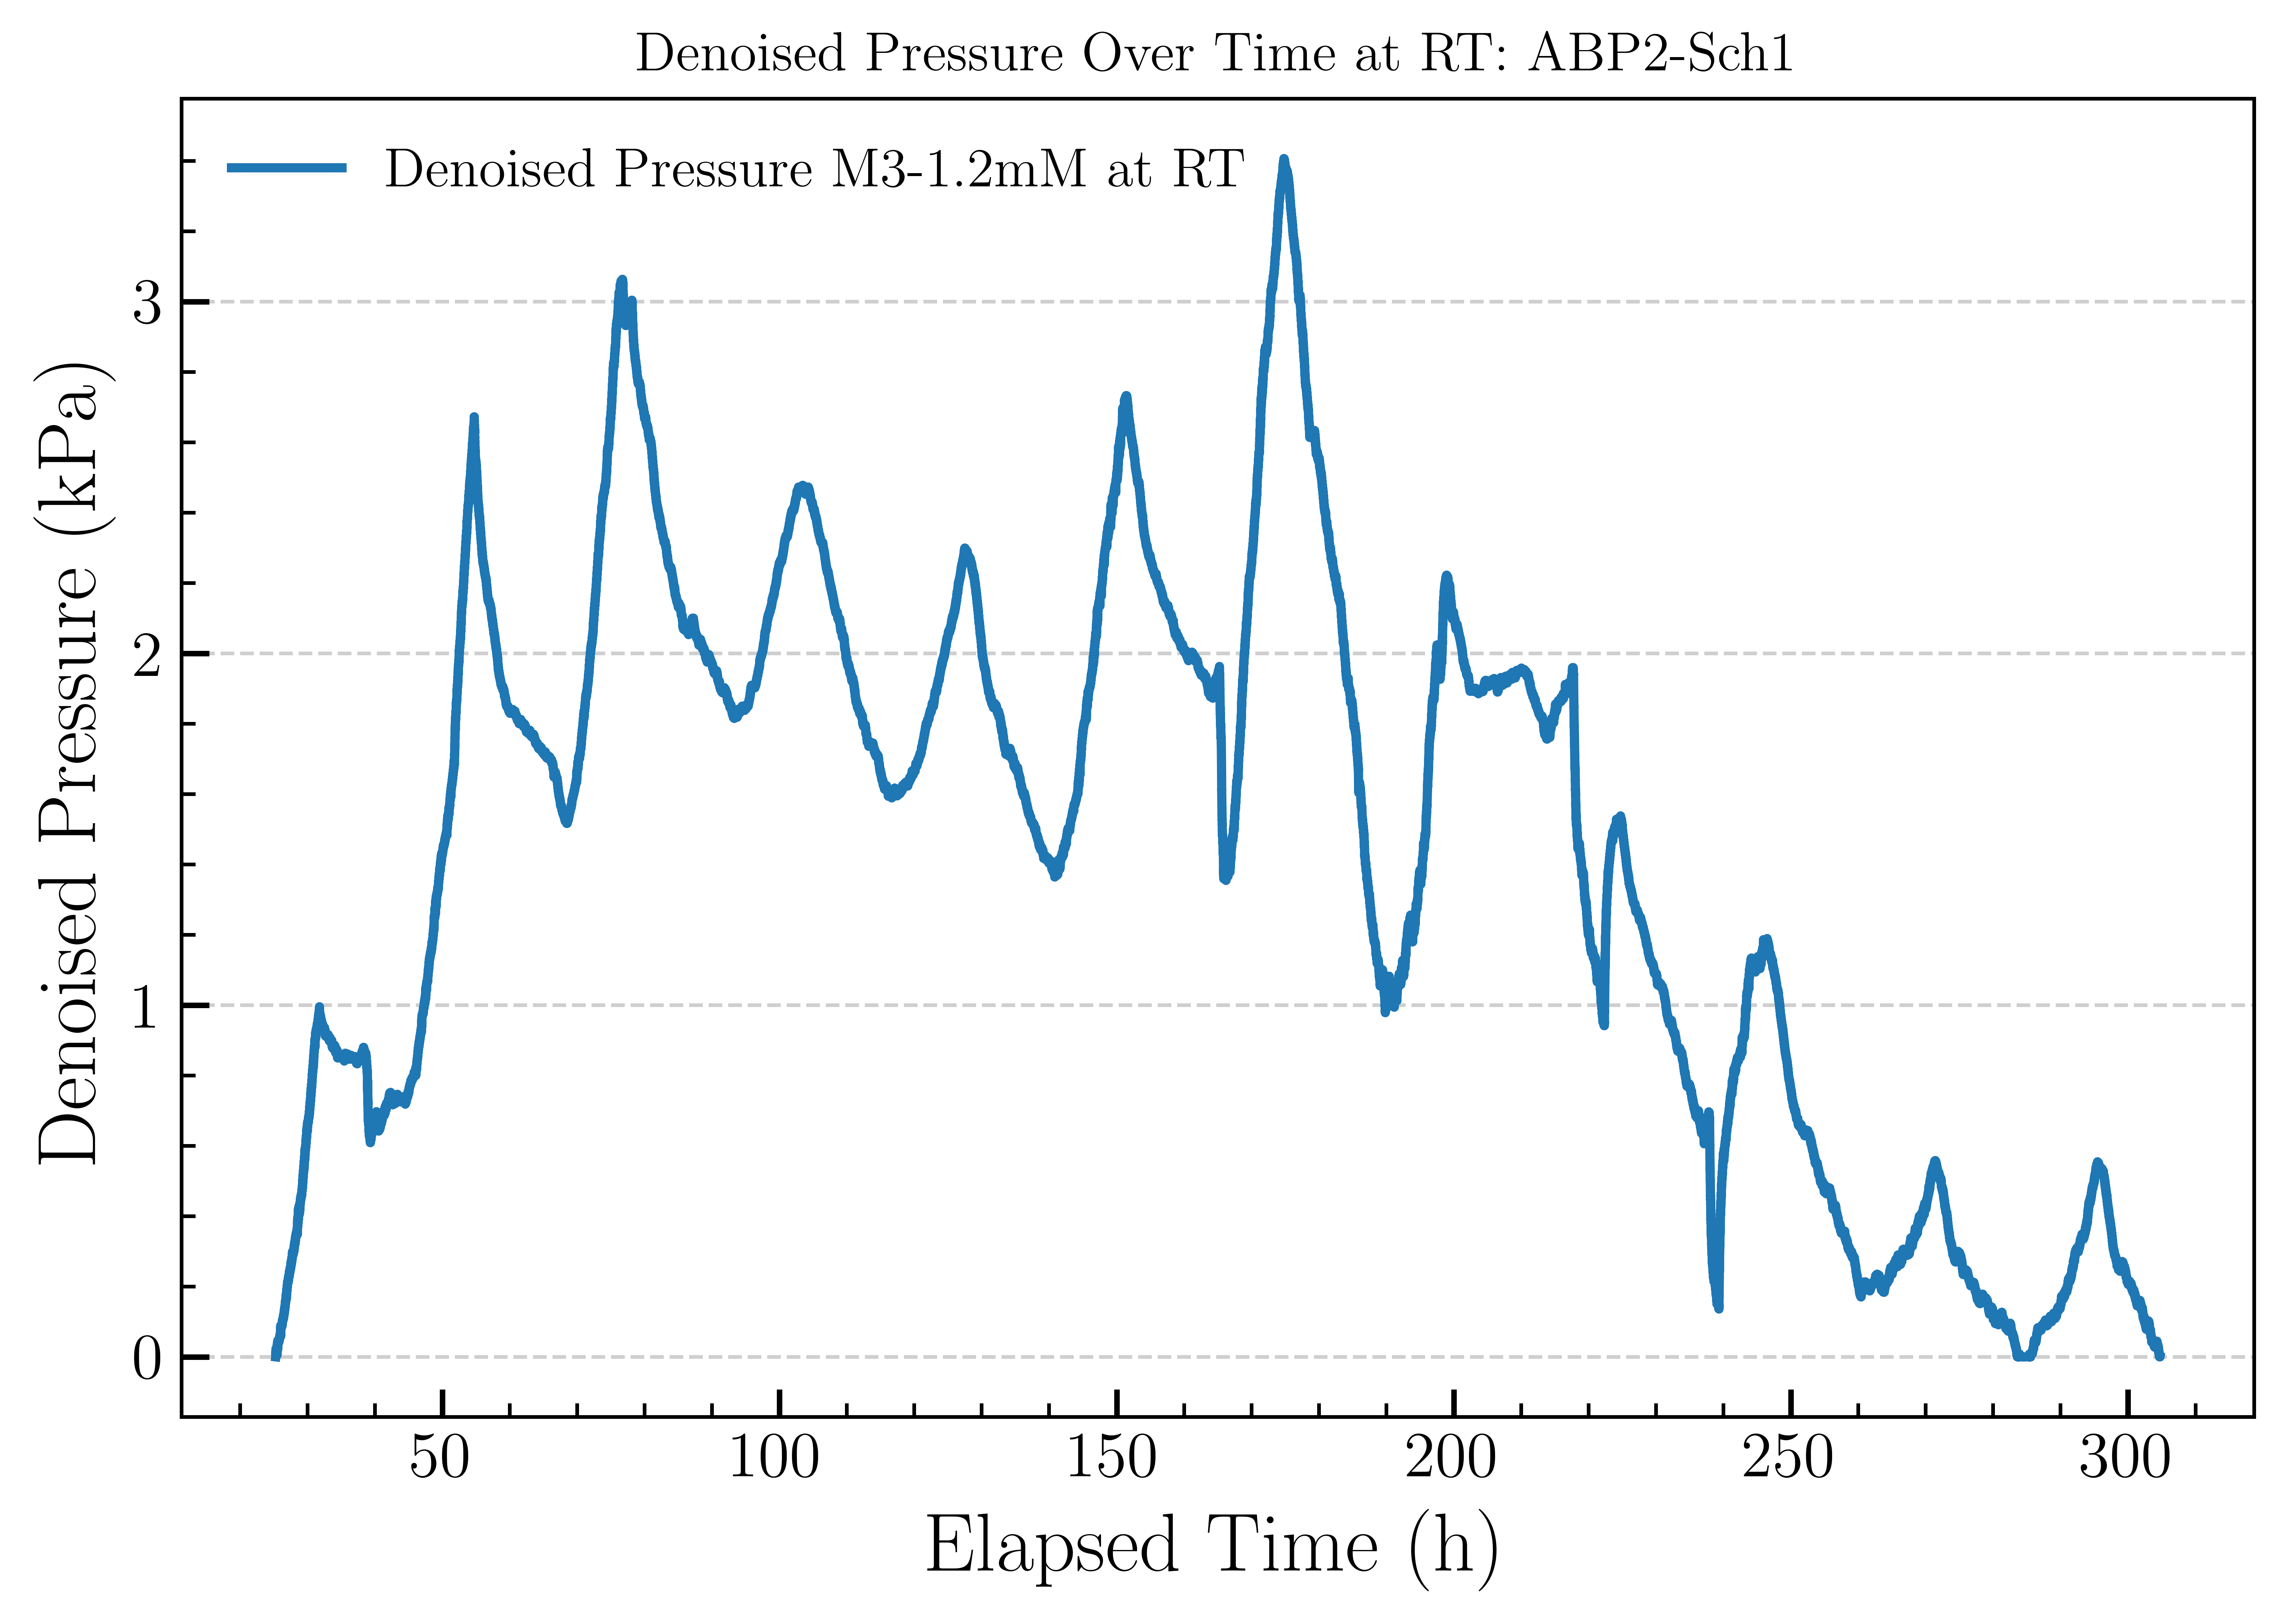

In [11]:
# 25 mins

df_trimmed_2 = df_trimmed[df_trimmed["Elapsed Time (hours)"] > 0.4166].reset_index(drop=True)


pd.DataFrame(df_trimmed_2).to_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\denoised_pressure_log_RT.csv", index=False)

fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_trimmed_2["Elapsed Time (hours)"], df_trimmed_2["ABP2-Sch1 (kPa)"], label=r"Denoised Pressure M3-1.2mM at RT", lw=2.0, color="tab:blue")
ax1.set_title("Denoised Pressure Over Time at RT: ABP2-Sch1")
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel=" Denoised Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

# since 25 seems perfect, use this 25 value in the denoising pipeline and then,

# generate the denoised csv from the python file

# raw vs denoised



In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\denoised_pressure_log_RT.csv"
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\processedcsv\M3_1.2mM_RT_pressure_o2_release.csv"

# Load data
df_main = pd.read_csv(main_path)
df_raw  = pd.read_csv(raw_path)

# Extract arrays for baseline correction
t_main = pd.to_numeric(df_main["Time (h)"], errors="coerce").to_numpy()
pressure_dwt = pd.to_numeric(df_main["DWT denoised pressure (kPa)"], errors="coerce").to_numpy()

# ---- Baseline-correct DWT by first 5 minutes ----
baseline_minutes = 5
baseline_end_h   = np.nanmin(t_main) + baseline_minutes/60.0
mask_base        = (t_main <= baseline_end_h)

dwt_baseline = np.nanmean(pressure_dwt[mask_base])
pressure_dwt_bc = pressure_dwt - dwt_baseline

# ---- Drop negative values ----
mask_nonneg = pressure_dwt_bc >= 0

# Apply mask to the whole dataframe
df_clean = df_main.loc[mask_nonneg].copy()

# Replace old DWT column with baseline-corrected version
df_clean["DWT denoised pressure (kPa) - BC"] = pressure_dwt_bc[mask_nonneg]

# Save cleaned CSV
out_path = r"C:\Users\chand\Documents\GitHub\Thesis\processedcsv\M3_1.2mM_RT_dwt_baseline_corrected.csv"
df_clean.to_csv(out_path, index=False)

print("Baseline correction applied:", round(dwt_baseline, 4), "kPa")
print("Original length:", len(df_main), "→ Cleaned length:", len(df_clean))
print("Saved to:", out_path)
print(df_clean.head())



print("DWT last value (BC):", pressure_dwt_bc[-1])
print("DWT first value (BC):", pressure_dwt_bc[0])


Baseline correction applied: 0.2369 kPa
Original length: 808944 → Cleaned length: 808795
Saved to: C:\Users\chand\Documents\GitHub\Thesis\processedcsv\M3_1.2mM_RT_dwt_baseline_corrected.csv
          Sample   Time (h)  DWT denoised pressure (kPa)  \
149  1.2 mM @ RT  25.334722                     0.236895   
150  1.2 mM @ RT  25.335000                     0.236915   
151  1.2 mM @ RT  25.335278                     0.236934   
152  1.2 mM @ RT  25.335556                     0.236954   
153  1.2 mM @ RT  25.335833                     0.236973   

     calibrated temperature (C)  O2 Released (µmol)  Smoothed Pressure (kPa)  \
149                   27.570002            0.378985                 0.003731   
150                   27.579998            0.379004                 0.003831   
151                   27.569996            0.379047                 0.005131   
152                   27.550006            0.379103                 0.003131   
153                   27.580000            0.3790

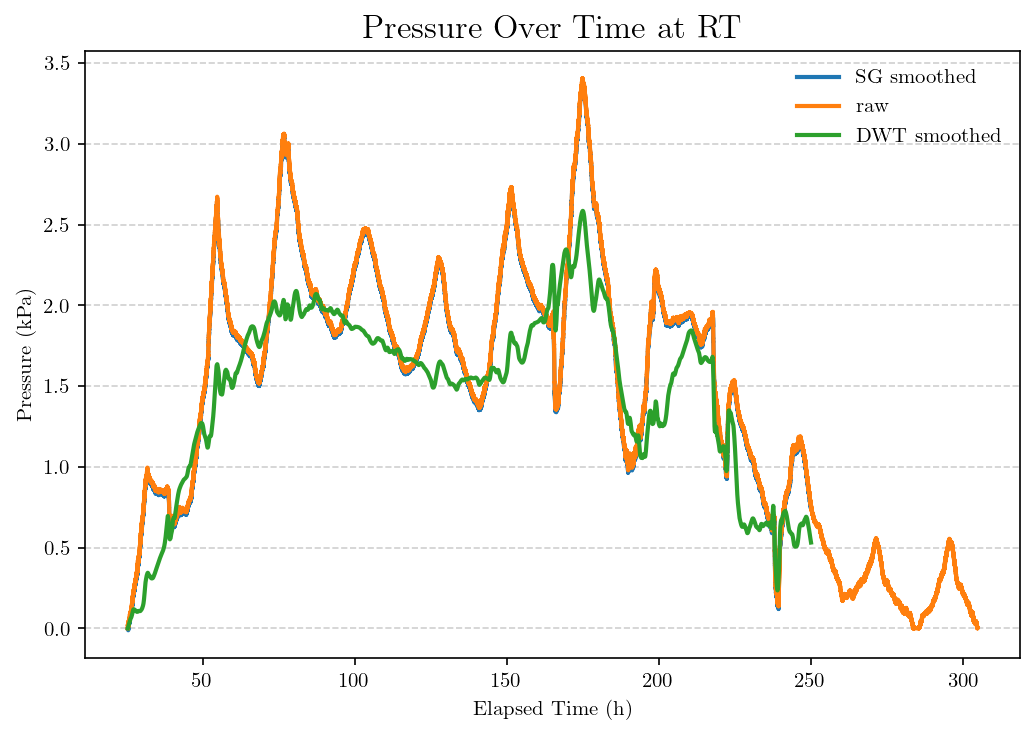

In [29]:



from matplotlib.pyplot import ylabel

raw_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\denoised_pressure_log_RT.csv"
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\processedcsv\M3_1.2mM_RT_dwt_baseline_corrected.csv"

# Load data
df_main = pd.read_csv(main_path)
df_raw = pd.read_csv(raw_path)
  
fig, ax = plt.subplots(figsize=(7,5), dpi=150)


t_raw = df_raw["Elapsed Time (hours)"]
t_main  = df_main["Time (h)"]
pressure_raw = df_raw["ABP2-Sch1 (kPa)"]
pressure_smoothed = df_main["Smoothed Pressure (kPa)"].values
dwt = df_main["DWT denoised pressure (kPa) - BC"].values
# Force baseline = 0
# pressure_smoothed = pressure_smoothed - pressure_smoothed[0]


ax.plot(t_main, pressure_smoothed,  lw=2.0, label="SG smoothed")
ax.plot(t_raw, pressure_raw, lw=2.0, label="raw")
ax.plot(t_main, dwt,  lw=2.0, label="DWT smoothed")



ax.set_title("Pressure Over Time at RT", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Pressure (kPa)")
ax.legend(frameon=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


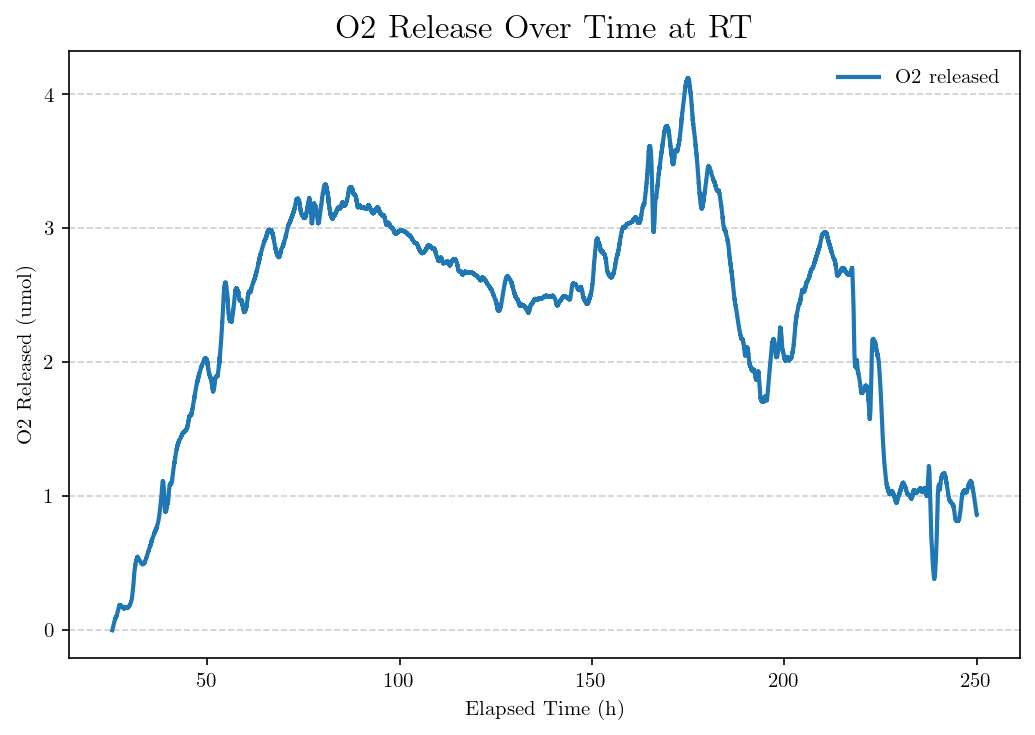

Baseline OO2 release (first 5 min): 0.3835 umol
Corrected CSV saved to: C:\Users\chand\Documents\GitHub\Thesis\processedcsv\2_M3_1.2mM_RT_o2release_baseline_corrected.csv


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your cleaned CSV
og_path = r"C:\Users\chand\Documents\GitHub\Thesis\processedcsv\M3_1.2mM_RT_dwt_baseline_corrected.csv"

# Load data
df_og_main = pd.read_csv(og_path)

# Extract values
t_og_main = pd.to_numeric(df_og_main["Time (h)"], errors="coerce").to_numpy()
o2_release = pd.to_numeric(df_og_main["O2 Released (µmol)"], errors="coerce").to_numpy()

# --- Baseline correction: first 5 minutes ---
baseline_minutes = 5
baseline_end_h   = np.nanmin(t_og_main) + baseline_minutes/60.0
mask_base        = (t_og_main <= baseline_end_h)

baseline_o2 = np.nanmean(o2_release[mask_base])
o2_release_bc = o2_release - baseline_o2

# Add baseline-corrected column to dataframe
df_og_main["O2 Released (µmol) - BC"] = o2_release_bc

# # Save updated dataframe
# out_path = r"C:\Users\chand\Documents\GitHub\Thesis\processedcsv\2_M3_1.2mM_RT_o2release_baseline_corrected.csv"
# df_og_main.to_csv(out_path, index=False)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ax.plot(t_og_main, o2_release_bc, lw=2.0, label="O2 released")
ax.set_title("O2 Release Over Time at RT", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("O2 Released (umol)")
ax.legend(frameon=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Baseline OO2 release (first {baseline_minutes} min): {baseline_o2:.4f} umol")
print("Corrected CSV saved to:", out_path)



In [ ]:
final_corrected_csv = r"C:\Users\chand\Documents\GitHub\Thesis\processedcsv\2_M3_1.2mM_RT_o2release_baseline_corrected.csv"




# SMOOTHED KPA IS NOT BASELINE CORRECXTED
df_final = pd.read_csv(final_corrected_csv)
print(max(df_final["O2 Released (µmol) - BC"]))
print(df_final.head())

4.120626284248361
        Sample   Time (h)  DWT denoised pressure (kPa)  \
0  1.2 mM @ RT  25.334722                     0.236895   
1  1.2 mM @ RT  25.335000                     0.236915   
2  1.2 mM @ RT  25.335278                     0.236934   
3  1.2 mM @ RT  25.335556                     0.236954   
4  1.2 mM @ RT  25.335833                     0.236973   

   calibrated temperature (C)  O2 Released (µmol)  Smoothed Pressure (kPa)  \
0                   27.570002            0.378985                 0.003731   
1                   27.579998            0.379004                 0.003831   
2                   27.569996            0.379047                 0.005131   
3                   27.550006            0.379103                 0.003131   
4                   27.580000            0.379097                 0.003231   

   % Conversion  Soln/Headspace Ratio  Max O2 Possible (µmol)  \
0      5.263683                   1.5                     7.2   
1      5.263939                   